# 2. Time Series Properties of Datasets

This chapter is dedicated mainly to time series analysis of the close price from the American futures market gold price dataset. The goal is to apply some classical statistical tests and models to extract useful time series characteristics for future model design.

In [ ]:
import numpy as np
import matplotlib as plt
import pandas as pd
from matplotlib.dates import YearLocator, MonthLocator, DayLocator, HourLocator, DateFormatter
from statsmodels.tsa.stattools import acf, pacf, adfuller

In [ ]:
dataset_gold = pd.read_csv("data/gold.csv", parse_dates=[0], index_col=0)
# Optimize data types
currencies = ['USD', 'EUR', 'JPY', 'CNY', 'RUB']
dataset_gold[currencies] = dataset_gold[currencies].apply(lambda series : series.str.replace(',', '.').str.replace('\xa0', '').astype('float64'))
dataset_gold.info()

In [ ]:
dataset_us_aug = pd.read_csv("data/gold_futures_with_indicators.csv", parse_dates=[0], index_col=0)

### Dataset Standartization

In [41]:
dataset_usd_gld = (dataset_gold['USD'] - dataset_gold['USD'].mean()) / dataset_gold['USD'].std()
dataset_aug_cls = (dataset_us_aug['Close'] - dataset_us_aug['Close'].mean()) / dataset_us_aug['Close'].std()

### Unit Root Test
The time series was visually observed to have a trend, which violates the stationary property of a series. Let us use the augmented Duckey-Fuller test to statistically prove that the series is indeed non-stationary.

Let $H_0$: the time series has a unit root (equivalently, time series is non-stationary), then find the $p$-value to reject or fail to reject this hypothesis.

In [42]:
# USD Gold Dataset
_, pvalue_usd_gld, *_ = adataset_aug_cls_reindexeduller(dataset_usd_gld)
pvalue_usd_gld

0.9980277371777525

Since $p$-value $> 0.05$, then there is **not enough** evidence to reject the null-hypothesis. Therefore, the time series is **non-stationary**.

In [43]:
# Futures Gold Dataset
_, pvalue_usd_gld, *_ = adataset_aug_cls_reindexeduller(dataset_aug_cls)
pvalue_usd_gld

0.9859360589638003

Since $p$-value $> 0.05$, then there is **not enough** evidence to reject the null-hypothesis. Therefore, the time series is **non-stationary**.

Non-stationarity implies that some of the following critria are violated:

(1) Mean is constant;

(2) Standard deviation is constant;

(3) No seasonality is present.

Based on the visual analysis, the datasets do not have any (annual) seasonality.

The first difference of components can solve the key problem of two datasets: existing trend. Due to this non-constant mean, the USD gold price and close price time series should be transformed to returns time series (first difference) as follows:

$z_t = y_t - y_{t-1}$, where $y_t$ is the USD gold price / close price time series. Considering the trend is linear, the $z_t$ would be stationary.

Note that the prediction of $z_t$ will happen, and to move back to $y_t$ given $t_f$ is the last recorded value of $y$, we have to do the following transformation:
$$
y_t = z_t + y_{t-1} = z_t + z_{t-1} + y_{t-2} = ... = \sum \limits _{k=0} ^{t_f-1} {z_{t-k}} + y_{t-t_f}
$$

In [44]:
returns_usd_gld = dataset_usd_gld.diff().dropna()
returns_us_aug = dataset_aug_cls.diff().dropna()

The new $p$-values are the following:

In [45]:
# USD Gold Dataset
_, pvalue_usd_gld, *_ = adataset_aug_cls_reindexeduller(returns_usd_gld)
pvalue_usd_gld

0.46900873813210436

In [46]:
# Futures Gold Dataset
_, pvalue_usd_gld, *_ = adataset_aug_cls_reindexeduller(returns_us_aug)
pvalue_usd_gld

0.0

For the USD gold price dataset, the series is still non-stationary but have corrected mean. However, the American futures market gold price time series was corrected to become stationary:

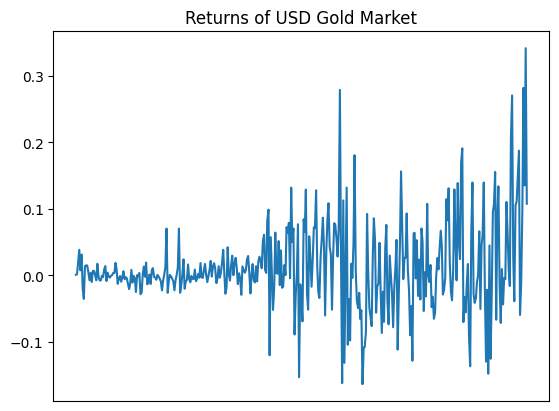

In [47]:
plt.plot(returns_usd_gld.index, returns_usd_gld)
plt.title("Returns of USD Gold Market")
_ = plt.xticks([])

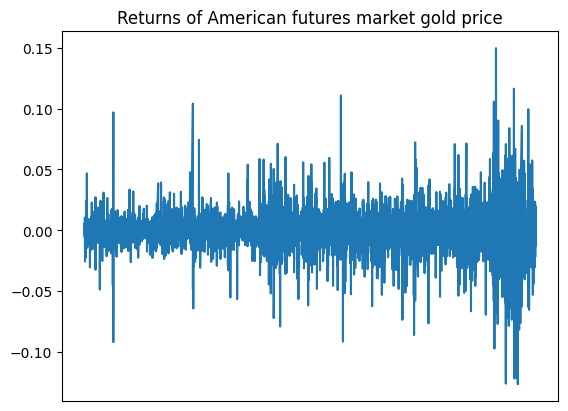

In [48]:
plt.plot(returns_us_aug.index, returns_us_aug)
plt.title("Returns of American futures market gold price")
_ = plt.xticks([])

The USD Gold dataset captures non-constant volatility, which can be fixed by the following transform: divide the time-series within each year by the standard deviation of time-series during this year:

In [49]:
usd_gld_annual_volatility = returns_usd_gld.groupby(returns_usd_gld.index.year).std()
usd_gld_annual_volatility_reindexed = returns_usd_gld.index.map(lambda d : usd_gld_annual_volatility.loc[d.year])

In [50]:
returns_usd_gld /= usd_gld_annual_volatility_reindexed

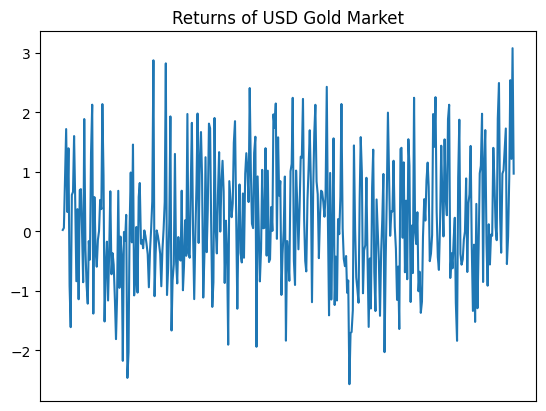

In [51]:
plt.plot(returns_usd_gld.index, returns_usd_gld)
plt.title("Returns of USD Gold Market")
_ = plt.xticks([])

In [52]:
# USD Gold Dataset
_, pvalue_usd_gld, *_ = adataset_aug_cls_reindexeduller(returns_usd_gld)
pvalue_usd_gld

3.6874609533690353e-25

Finally, the $p$-value is sufficient to reject the null-hypothesis for the USD gold dataset as well.

### Autocorrelation Function (ACF)

Autocorrelation function is a transformation of the original data in the form of correlation components at different lags. Each correlation is evaluated between the last observation $y_t$ and the lagged by $k$ observation $y_{t-k}$. Additionally, the correlation also includes all indirect components such as dependency of $y_{t}$ on $y_{t-k}$ through $y_{t-k+m}$, where $0 < m < k$.

Moreover, the significance area is computed to detect correlation components that statistically matter.

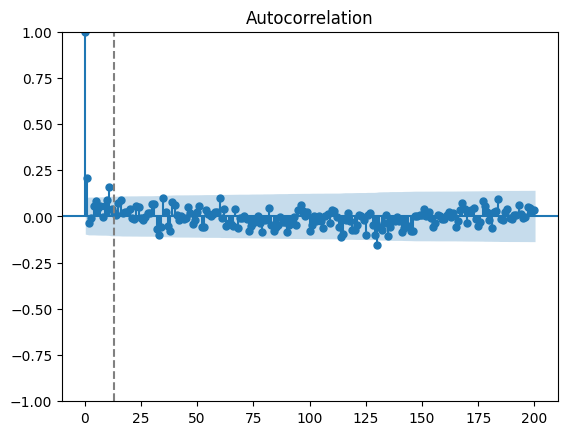

In [53]:
# USD Gold Dataset
gld_acf = plot_acf(returns_usd_gld, lags=200)
gld_acf.axes[0].axvline(x=13, linestyle='--', color='grey')

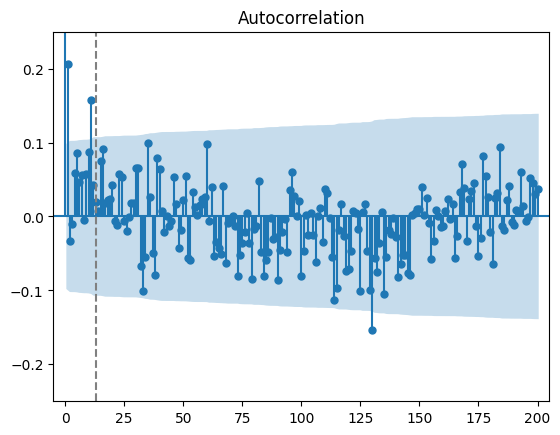

In [54]:
gld_acf.axes[0].set_xlim([-5, 205])
gld_acf.axes[0].set_ylim([-0.25, .25])
gld_acf

Based on the plot, the first $11$ components are worth to be considered as features for this dataset. From the definition of the Moving Average (MA) model, the order of MA model is set from the number of significant components. Therefore, $\text{MA}(13)$ model can be used to model the process.

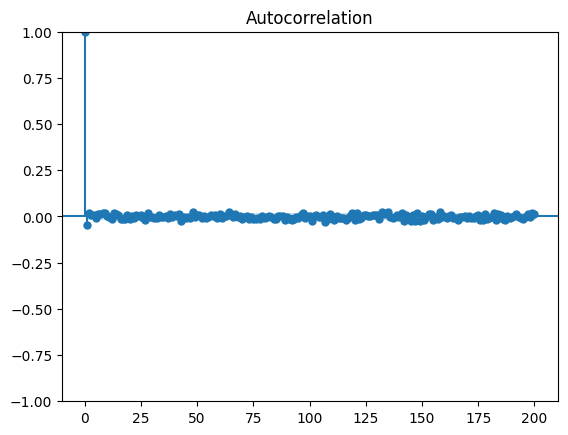

In [55]:
# Futures Gold Dataset
gld_us_aug_acf = plot_acf(returns_us_aug, lags=200)

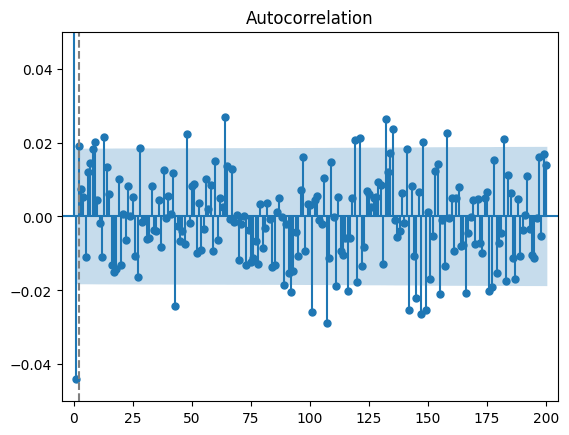

In [56]:
gld_us_aug_acf.axes[0].set_xlim([-5, 205])
gld_us_aug_acf.axes[0].set_ylim([-0.05, .05])
gld_us_aug_acf.axes[0].axvline(x=2, linestyle='--', color='grey')
gld_us_aug_acf

The number of significant lags can evaluated to be around $2$ with lags having some small impact on the target. Thus, $\text{MA}(2)$ may model this process but the autocorrelation seems to be poor.

### Partial Autocorrelation Function (PACF)

PACF suggest the direct contribution of the lagged moment to the prediction of the value of the time series at time $t$. The PACF reduces the indirect contribution of forward components observed in the ACF analysis.

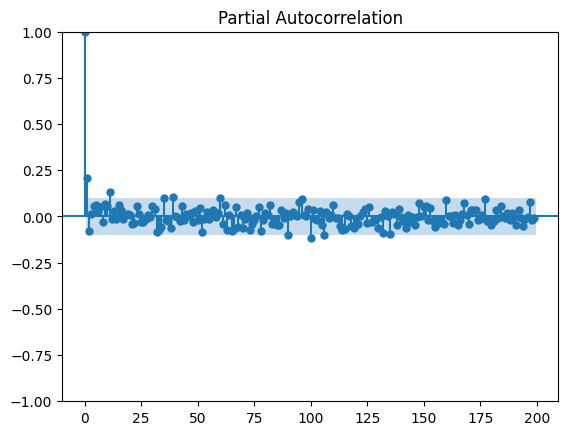

In [57]:
# USD Gold Dataset
ax = plt.axes()
gld_pacf = plot_pacf(returns_usd_gld, lags=len(returns_usd_gld)/2, ax=ax)

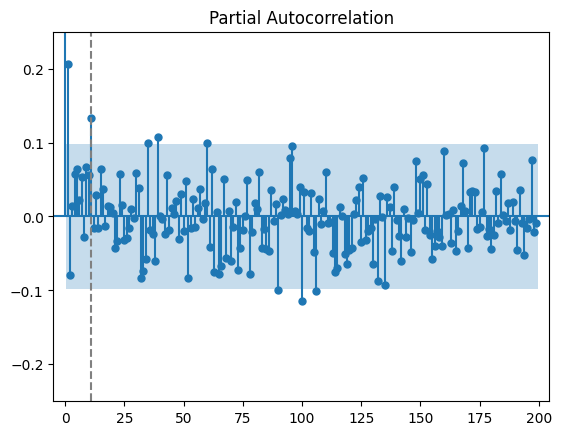

In [58]:
gld_pacf.axes[0].set_xlim([-5, len(returns_usd_gld)/2 + 5])
gld_pacf.axes[0].set_ylim([-0.25, .25])
gld_pacf.axes[0].axvline(x=11, linestyle='--', color='grey')
gld_pacf

Based on the plot, the first $11$ lags limit have some direct correlation with the target. The correlation is observed to slowly converge towards zero. The order of the autoregressive model is defined to be the number of significant lags. Thus, $\text{AR}(11)$ down to $\text{AR}(3)$ can model this process.

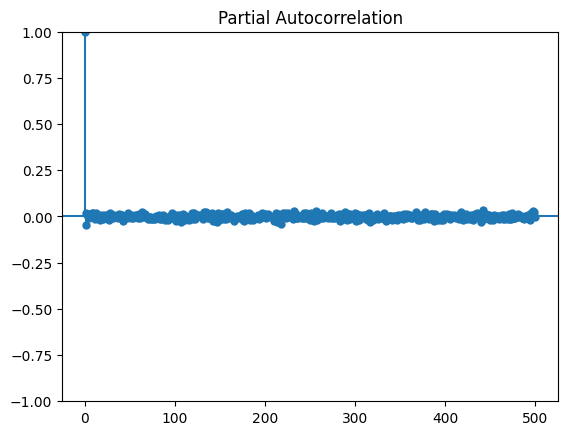

In [59]:
# Futures Gold Dataset
ax = plt.axes()
gld_us_aug_pacf = plot_pacf(returns_us_aug, lags=500, ax=ax)

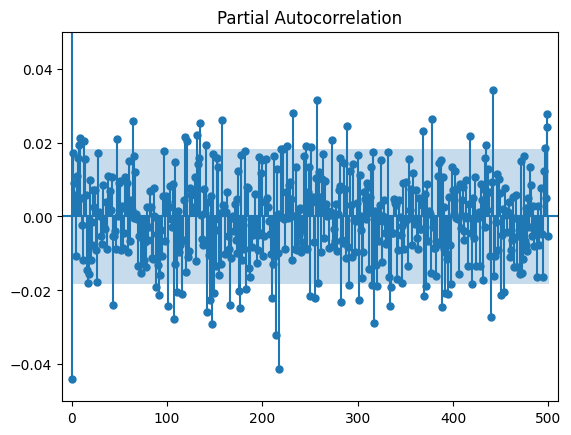

In [60]:
gld_us_aug_pacf.axes[0].set_xlim([-10, 510])
gld_us_aug_pacf.axes[0].set_ylim([-0.05, .05])
gld_us_aug_pacf

In contrast, the hourly measured gold price time series features insignificant correlations without any convergence. Although $\text{AR}(p)$ model may be tested with some small parameter $p$, the series seem to be uncorrelated of its past values.